In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
import os

print(os.getcwd())

/Users/ehsanalamgir/Desktop/IDS102_A3/Project


In [3]:
import pandas as pd

df = pd.read_csv("/Users/ehsanalamgir/Desktop/IDS102_A3/Project/Dataset.csv")

In [4]:
df = df.drop(
    columns=["Gender", "Country", "Daily_Unlocks"]
)

In [5]:
df.head()

,Age,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Undergraduate,Facebook,Networking,4.0,4.5,2.2,6.7,Medium,6.8
1,23,Graduate,LinkedIn,Education,1.6,7.0,2.4,8.6,Low,7.6
2,22,Undergraduate,Instagram,Entertainment,4.6,4.0,1.8,6.7,Medium,7.0
3,18,High School,Snapchat,Entertainment,7.0,1.0,1.7,5.4,Very High,5.3
4,24,Graduate,Facebook,Networking,7.5,1.0,1.1,5.0,Very High,4.4


In [6]:
df.shape

(5000, 10)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Academic_Level           5000 non-null   str    
 2   Most_Used_Platform       5000 non-null   str    
 3   Purpose_Of_Use           5000 non-null   str    
 4   Avg_Daily_Usage_Hours    5000 non-null   float64
 5   Study_Hours              5000 non-null   float64
 6   Physical_Activity_Hours  5000 non-null   float64
 7   Sleep_Hours_Per_Night    5000 non-null   float64
 8   Stress_Level             5000 non-null   str    
 9   Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(1), str(4)
memory usage: 390.8 KB


In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,8.300000,4.100000,9.900000,9.400000


In [9]:
df.isnull().sum()

Age                        0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(6)

In [12]:
df.nunique()

Age                         7
Academic_Level              3
Most_Used_Platform         12
Purpose_Of_Use              4
Avg_Daily_Usage_Hours      79
Study_Hours                76
Physical_Activity_Hours    44
Sleep_Hours_Per_Night      63
Stress_Level                4
Mental_Health_Score        59
dtype: int64

In [13]:
correlation = df.corr(numeric_only=True)

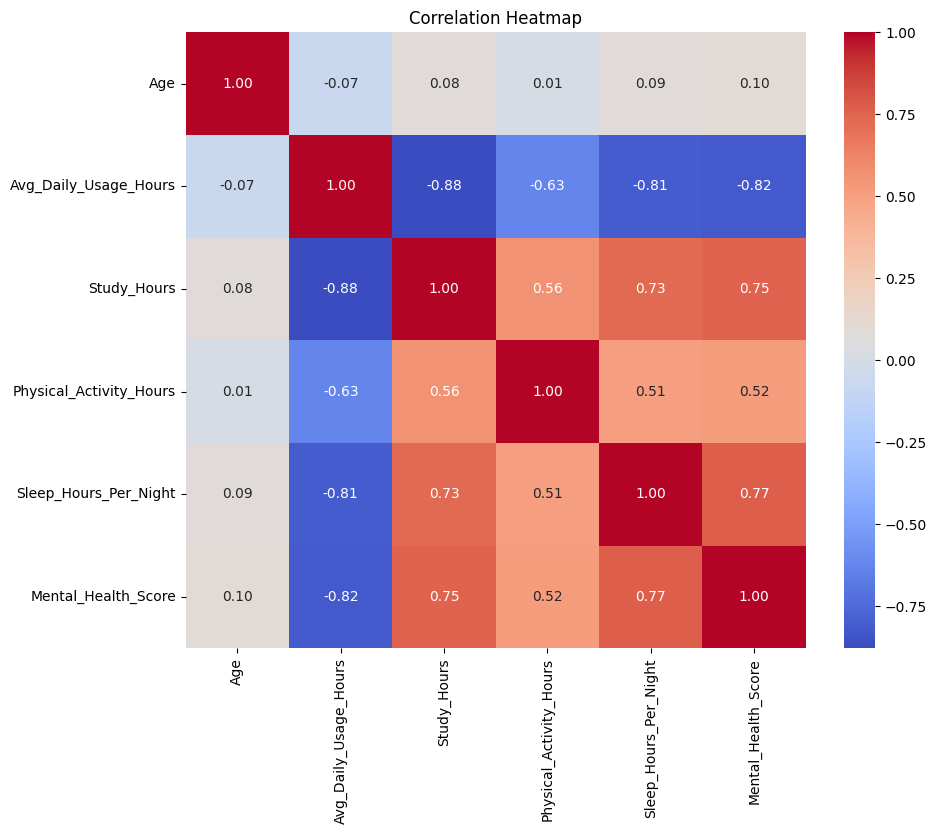

In [14]:


plt.figure(figsize=(10,8))


sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [15]:
df.std(numeric_only=True)

Age                        1.736620
Avg_Daily_Usage_Hours      1.653913
Study_Hours                1.637018
Physical_Activity_Hours    0.668398
Sleep_Hours_Per_Night      1.221391
Mental_Health_Score        1.278701
dtype: float64

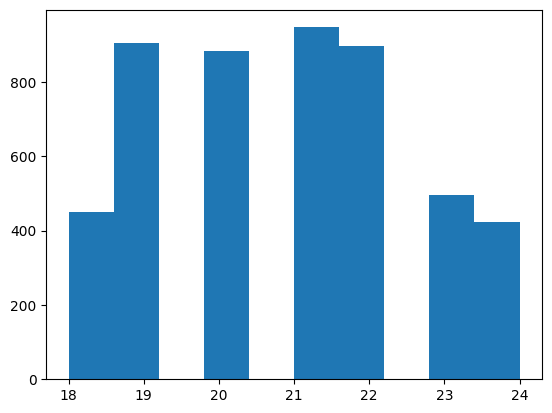

In [16]:
plt.hist(df["Age"])
plt.show()

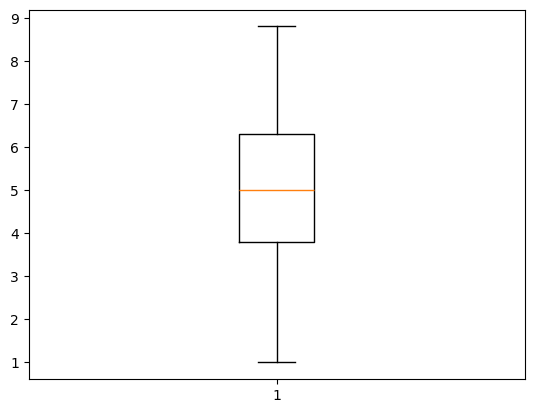

In [17]:
plt.boxplot(df["Avg_Daily_Usage_Hours"])
plt.show()

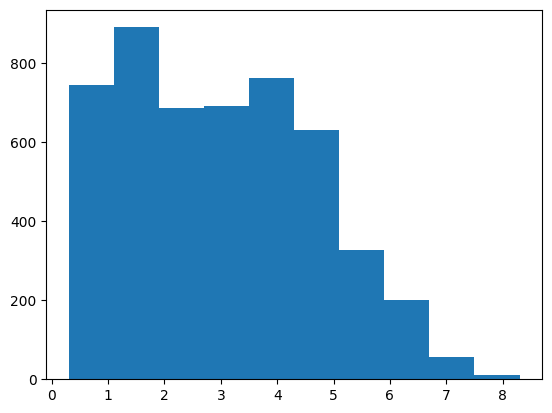

In [18]:
plt.hist(df["Study_Hours"])
plt.show()

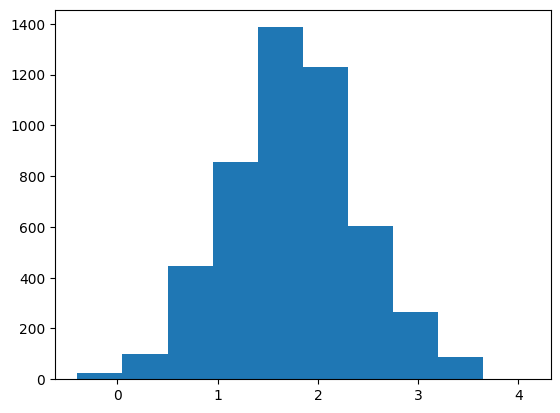

In [19]:
plt.hist(df["Physical_Activity_Hours"])
plt.show()

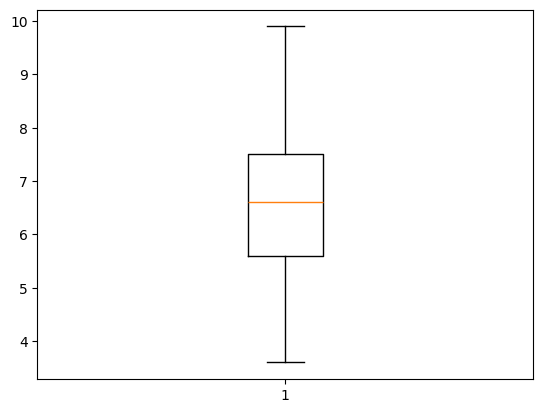

In [20]:
plt.boxplot(df["Sleep_Hours_Per_Night"])
plt.show()

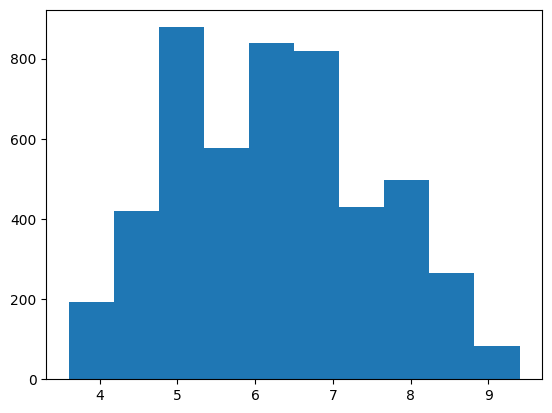

In [21]:
plt.hist(df["Mental_Health_Score"])
plt.show()

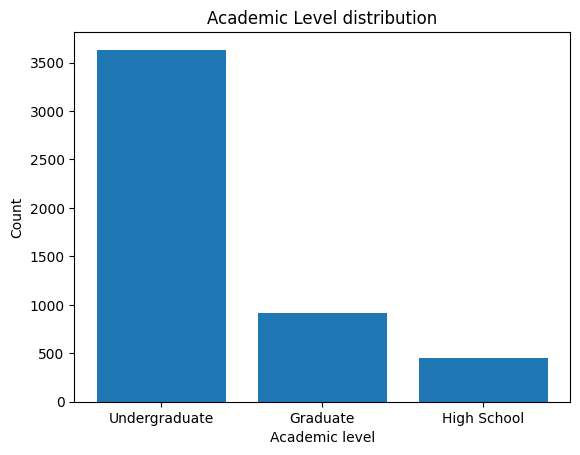

In [22]:
academic =df["Academic_Level"].value_counts()
plt.bar(academic.index,academic.values)
plt.title("Academic Level distribution")
plt.xlabel("Academic level")
plt.ylabel("Count")
plt.show()

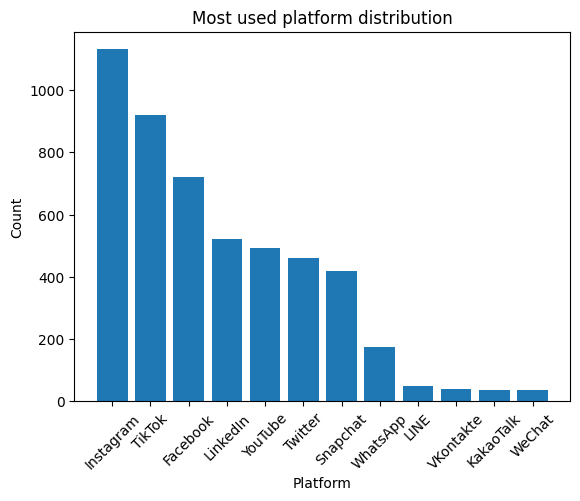

In [23]:
platform = df["Most_Used_Platform"].value_counts()
plt.bar(platform.index,platform.values)
plt.title("Most used platform distribution")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

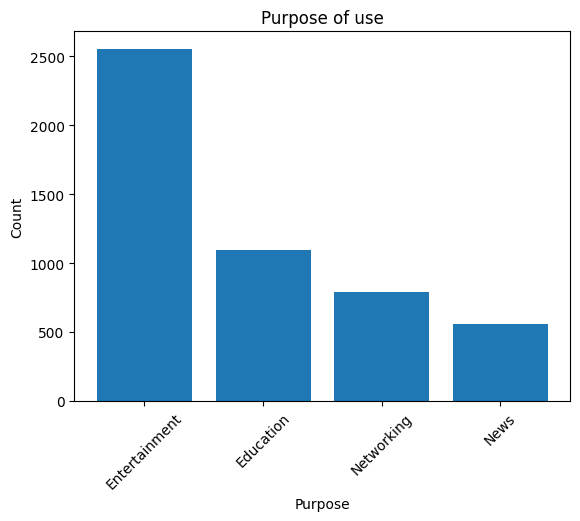

In [24]:
purpose = df["Purpose_Of_Use"].value_counts()
plt.bar(purpose.index, purpose.values)
plt.title("Purpose of use")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Academic_Level', ylabel='Study_Hours'>

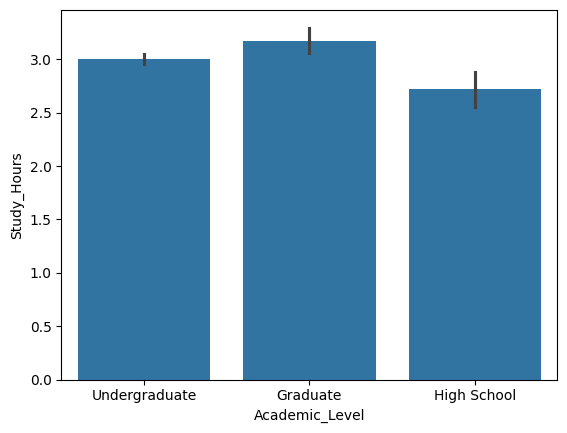

In [25]:
df.groupby("Academic_Level")["Study_Hours"].mean()
sns.barplot(x="Academic_Level", y="Study_Hours", data=df)

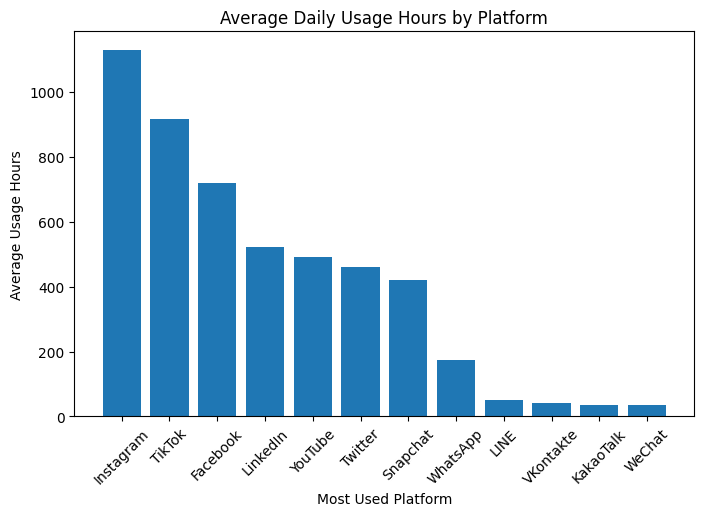

In [26]:
df.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].mean()
plt.figure(figsize=(8,5))
plt.bar(platform.index, platform.values)
plt.title("Average Daily Usage Hours by Platform")
plt.xlabel("Most Used Platform")
plt.ylabel("Average Usage Hours")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Purpose_Of_Use', ylabel='Mental_Health_Score'>

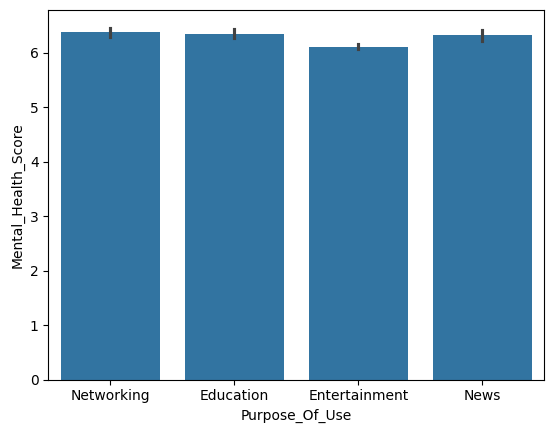

In [27]:
df.groupby("Purpose_Of_Use")["Mental_Health_Score"].mean()
sns.barplot(x="Purpose_Of_Use", y="Mental_Health_Score", data=df)

<Axes: xlabel='Age', ylabel='Mental_Health_Score'>

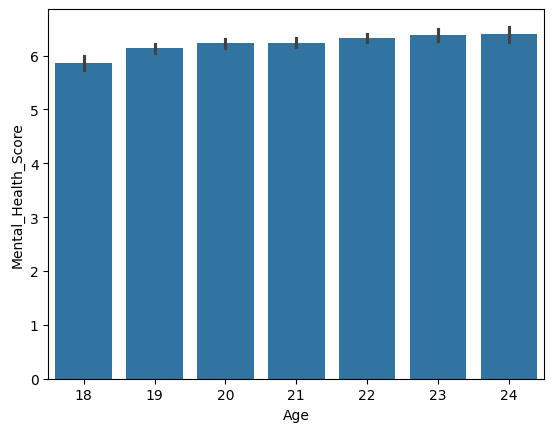

In [28]:
df.groupby("Age")["Mental_Health_Score"].mean().max()
sns.barplot(x="Age", y="Mental_Health_Score", data=df)

In [29]:
X = df.drop("Mental_Health_Score", axis=1)

y = df["Mental_Health_Score"]

In [30]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
   
    "Academic_Level",
    "Most_Used_Platform",
    "Purpose_Of_Use",
    "Stress_Level"
]

for col in categorical_columns:
    label_encoder = LabelEncoder()
    X[col] =label_encoder.fit_transform(X[col])

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
print(X.dtypes)
print(X_train.dtypes)

Age                          int64
Academic_Level               int64
Most_Used_Platform           int64
Purpose_Of_Use               int64
Avg_Daily_Usage_Hours      float64
Study_Hours                float64
Physical_Activity_Hours    float64
Sleep_Hours_Per_Night      float64
Stress_Level                 int64
dtype: object
Age                          int64
Academic_Level               int64
Most_Used_Platform           int64
Purpose_Of_Use               int64
Avg_Daily_Usage_Hours      float64
Study_Hours                float64
Physical_Activity_Hours    float64
Sleep_Hours_Per_Night      float64
Stress_Level                 int64
dtype: object


In [33]:
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
Mental_Health_Indicator =linear_model.predict(X_test)

In [35]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": Mental_Health_Indicator
})

print(comparison.head(5))

   Actual  Predicted
0     7.0   6.844571
1     8.1   7.753575
2     5.1   5.778478
3     6.0   5.943026
4     6.8   6.666922


In [36]:
print("R2 Score:", r2_score(y_test, Mental_Health_Indicator))
print("MAE:", mean_absolute_error(y_test,Mental_Health_Indicator))
print("MSE:", mean_squared_error(y_test, Mental_Health_Indicator))

R2 Score: 0.7425081738521319
MAE: 0.5267142534916721
MSE: 0.4465230027189988


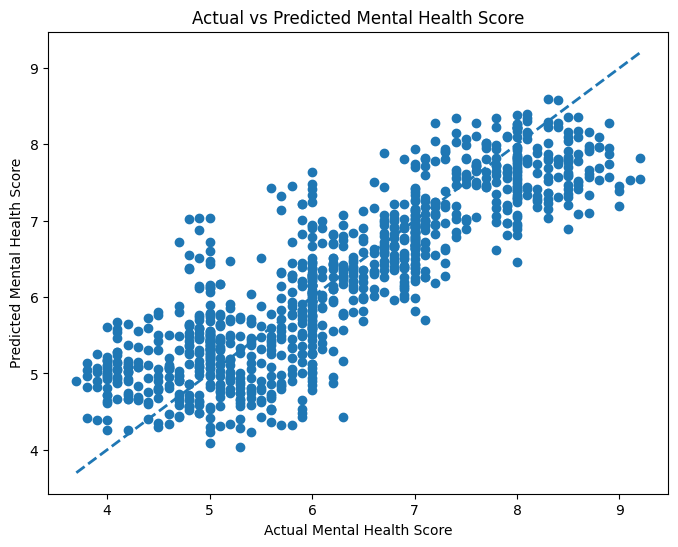

In [37]:


plt.figure(figsize=(8, 6))

plt.scatter(y_test, Mental_Health_Indicator)
min_value = min(y_test.min(), Mental_Health_Indicator.min())
max_value = max(y_test.max(),Mental_Health_Indicator.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)


plt.xlabel("Actual Mental Health Score")
plt.ylabel("Predicted Mental Health Score")
plt.title("Actual vs Predicted Mental Health Score")

plt.show()

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                   Feature  Coefficient  Importance
4    Avg_Daily_Usage_Hours    -0.356270    0.356270
7    Sleep_Hours_Per_Night     0.314036    0.314036
5              Study_Hours     0.098512    0.098512
3           Purpose_Of_Use     0.044490    0.044490
6  Physical_Activity_Hours     0.030366    0.030366
8             Stress_Level     0.023333    0.023333
2       Most_Used_Platform     0.020402    0.020402
0                      Age     0.019069    0.019069
1           Academic_Level    -0.008676    0.008676
